In [2]:
import os
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

In [3]:
def smooth_network(network, window=11, poly=3):
    """
    Smooth all S-parameters of a Network using Savitzky–Golay filter.
    Returns a new smoothed Network.
    """
    s = network.s.copy()
    n_freq, n_port, _ = s.shape

    s_smooth = np.zeros_like(s, dtype=complex)

    for i in range(n_port):
        for j in range(n_port):
            real_part = np.real(s[:, i, j])
            imag_part = np.imag(s[:, i, j])

            real_smooth = savgol_filter(real_part, window, poly)
            imag_smooth = savgol_filter(imag_part, window, poly)

            s_smooth[:, i, j] = real_smooth + 1j * imag_smooth

    smoothed_network = rf.Network(
        frequency=network.frequency,
        s=s_smooth,
        z0=network.z0
    )

    return smoothed_network


def load_directory(directory_path, window=30, poly=3):
    """
    Reads all .s2p files in a directory.
    Can Return two lists:
        {directory_name}_original
        {directory_name}_smoothed
    """

    directory_name = os.path.basename(os.path.normpath(directory_path))

    original_list = []
    smoothed_list = []

    for file in sorted(os.listdir(directory_path)):
        if file.lower().endswith(".s2p"):

            full_path = os.path.join(directory_path, file)

            # Load original network
            ntwk = rf.Network(full_path)

            # Use filename (without extension) as network name
            name = os.path.splitext(file)[0]
            ntwk.name = name

            original_list.append(ntwk)

            # Create smoothed version
            ntwk_smooth = smooth_network(ntwk, window, poly)
            ntwk_smooth.name = name

            smoothed_list.append(ntwk_smooth)

    # Dynamically create variable names
    globals()[f"{directory_name}_measured"] = original_list
    globals()[f"{directory_name}_smoothed"] = smoothed_list

    return original_list, smoothed_list


def avg_return_loss(ntwk):
    s11_db = ntwk.s_db[:,0,0]
    return np.mean(s11_db)
def worst_return_loss(ntwk):
    return np.max(ntwk.s_db[:640,0,0])   # closest to 0 dB
def avg_transmit_loss(ntwk):
    s11_db = ntwk.s_db[:,1,0]
    return np.mean(s11_db)
def worst_transmit_loss(ntwk):
    return np.max(ntwk.s_db[:,1,0])   # closest to 0 dB

In [4]:
from pathlib import Path
path1 = Path('PRL_meas_Hrithik_13_may_FCB')
path2 = Path('GEECI_mes')

prl_files = []
geeci_files = []
directory = path1
for file in directory.iterdir():
    prl_files.append(file)
directory = path2
for file in directory.iterdir():
    geeci_files.append(file)



## Comparison between GEECI and PRL VNA

In [5]:
SetA_DMD_measured, SetA_DMD_Smoothened = load_directory(r'PRL_meas_Hrithik_13_may_FCB\SUB4(DMD)', window=16, poly=3)
SetA_DMD_measured

[2-Port Network: 'ref_1',  1000000000.0-40000000000.0 Hz, 391 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'ref_1_sapphire',  1000000000.0-40000000000.0 Hz, 391 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'ref_2',  1000000000.0-40000000000.0 Hz, 391 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'ref_2_sapphire',  1000000000.0-40000000000.0 Hz, 391 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'ref_4_sapphire',  1000000000.0-40000000000.0 Hz, 391 pts, z0=[50.+0.j 50.+0.j]]

In [6]:
SetC_DMD_measured, SetC_DMD_Smoothened = load_directory(r'GEECI_mes\SETC\SUB4(DMD)', window=16, poly=3)
SetC_DMD_measured

[2-Port Network: 'TN1',  1000000000.0-45000000000.0 Hz, 441 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'TN2',  1000000000.0-45000000000.0 Hz, 441 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'TN3',  1000000000.0-45000000000.0 Hz, 441 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'TN4',  1000000000.0-45000000000.0 Hz, 441 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'TN5',  1000000000.0-45000000000.0 Hz, 441 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'TN6',  1000000000.0-45000000000.0 Hz, 441 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'thru_ref_nos1',  1000000000.0-45000000000.0 Hz, 441 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'thru_ref_nos2',  1000000000.0-45000000000.0 Hz, 441 pts, z0=[50.+0.j 50.+0.j]]

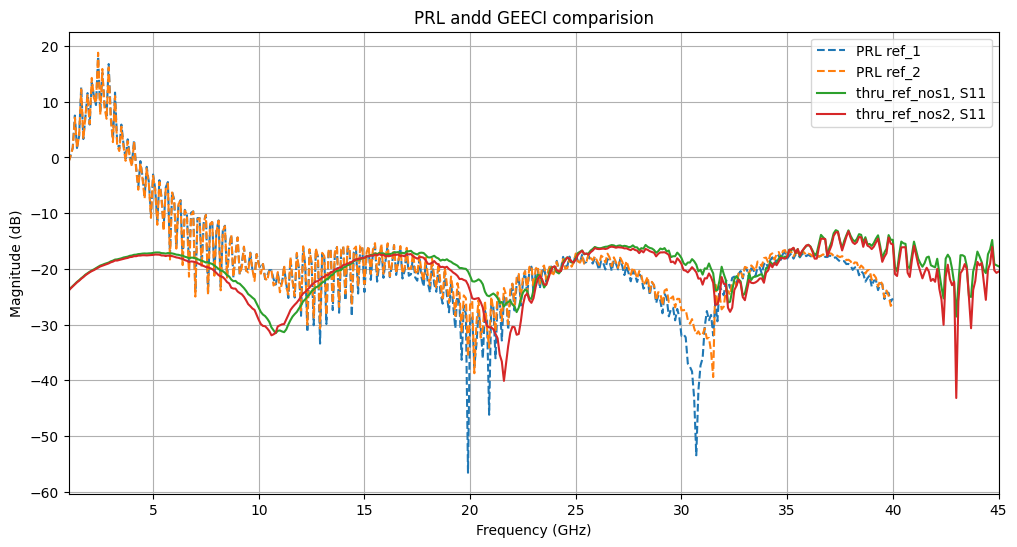

In [7]:
#lets comapre geeci and PRL results once:
plt.figure(figsize=(12,6))
plt.title("PRL andd GEECI comparision")
plt.grid()
for ntwk in [SetA_DMD_measured[x] for x in (0,2)]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0, linestyle='--', label=f"PRL {ntwk.name}")
for ntwk in SetC_DMD_measured[-2:]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0)    

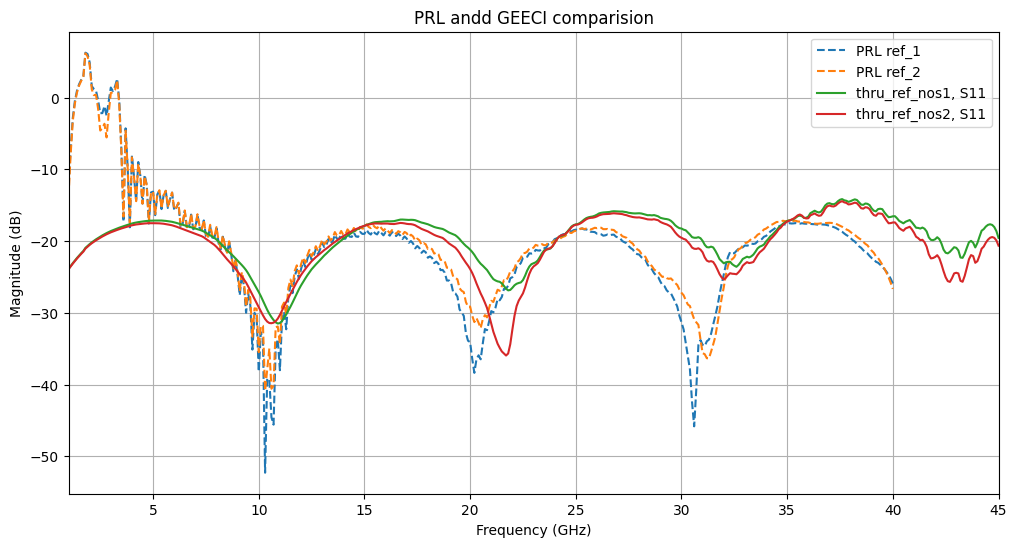

In [8]:
#lets comapre geeci and PRL results once:
plt.figure(figsize=(12,6))
plt.title("PRL andd GEECI comparision")
plt.grid()
for ntwk in [SetA_DMD_Smoothened[x] for x in (0,2)]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0, linestyle='--', label=f"PRL {ntwk.name}")
for ntwk in SetC_DMD_Smoothened[-2:]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0)   

## Phase 1 : The BAseline and repeatability of measurements

### PLot of through line references overlapped on each other

In [9]:
# refrencing files with the same names across different samples:
from pathlib import Path

# Define the parent directory
parent_dir = Path("GEECI_mes")

# list to contain paths of all files found
thru_files_nos1 = []
thru_files_nos2 = []
thru_files_nos3 = []
thru_files_all = []

FCB_tr_overlap_30um = []
FCB_pillar_pitch_100um = []
# Search for files containing specific characters (e.g., "target")
# The '**' searches all subfolders recursively



matching_files = list(parent_dir.glob("**/*thru_ref*.*"))
for file_path in matching_files:
    # print(f"Found file: {file_path.name} in {file_path.parent}")
    thru_files_all.append(file_path)

# Loop through and reference each file
matching_files1 = list(parent_dir.glob("**/*thru_ref_nos1*.*"))
for file_path in matching_files1:
    # print(f"Found file: {file_path.name} in {file_path.parent}")
    thru_files_nos1.append(file_path)

matching_files2 = list(parent_dir.glob("**/*thru_ref_nos2*.*"))
for file_path in matching_files2:
    # print(f"Found file: {file_path.name} in {file_path.parent}")
    thru_files_nos2.append(file_path)

matching_files3 = list(parent_dir.glob("**/*thru_ref_nos3*.*"))
for file_path in matching_files3:
    # print(f"Found file: {file_path.name} in {file_path.parent}")
    thru_files_nos3.append(file_path)
# type(thru_files_all[1])

matching_files4 = list(parent_dir.glob("**/*30*.*"))
for file_path in matching_files4:
    # print(f"Found file: {file_path.name} in {file_path.parent}")
    FCB_tr_overlap_30um.append(file_path)

matching_files5 = list(parent_dir.glob("**/*120*.*"))
for file_path in matching_files5:
    print(f"Found file: {file_path.name} in {file_path.parent}")
    FCB_pillar_pitch_100um.append(file_path)


Found file: TN1_120um.s2p in GEECI_mes\SetC\SUB2
Found file: TN3_120um.s2p in GEECI_mes\SetC\SUB2
Found file: TN1_120um.s2p in GEECI_mes\SetB\SUB2
Found file: TN3_120um.s2p in GEECI_mes\SetB\SUB2


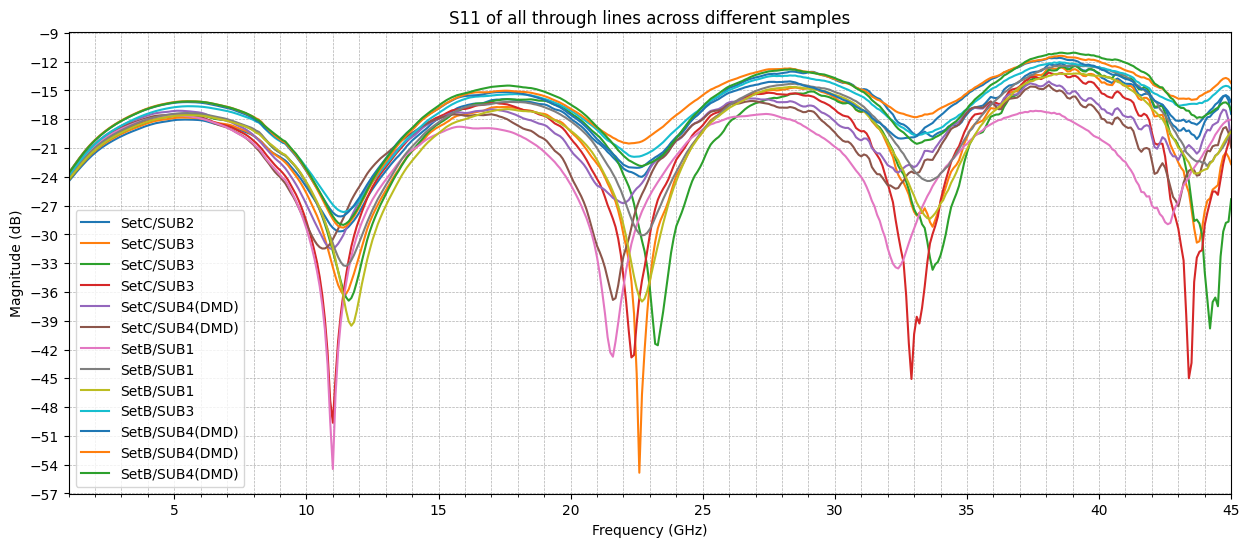

In [107]:
from matplotlib import ticker
from scipy.signal import find_peaks
dip1_freqs = []
dip2_freqs = []
dip3_freqs = []
dip4_freqs = []
# plotting the S11 of through lines nos1
plt.figure(figsize=(15,6))
plt.title("S11 of all through lines across different samples")

#changinf axis ticks
from matplotlib.ticker import MultipleLocator
ax = plt.gca()
# Set grid lines at every 3 dB on the y-axis
ax.yaxis.set_major_locator(MultipleLocator(3))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1e9))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

for path in thru_files_all:
    path_obj = Path(path)
    # Extract the last two directories (excluding the file name)
    # path_obj.parts contains ('C:', 'Users', ..., 'TrialA', 'results.csv')
    folder_label = "/".join(path_obj.parts[-3:-1])  # Get the last two directories

    ntwk = rf.Network(path)
    sm_ntwk = smooth_network(ntwk, window=11, poly=3)
    sm_ntwk.frequency.unit = 'GHz'
    sm_ntwk.plot_s_db(m=0,n=0, label=folder_label)



In [111]:
for path in thru_files_all:
    path_obj = Path(path)    
    ntwk = rf.Network(path)
    sm_ntwk = smooth_network(ntwk, window=11, poly=3)
    sm_ntwk.frequency.unit = 'GHz'
    s11_db = sm_ntwk.s_db[:, 0, 0]  # Extract S11 in dB
    # print(s11_db)
    peaks, _ = find_peaks(-s11_db, height=10, distance = 80) # 'height=10' finds dips deeper than -10dB
    # print(peaks)
    dip1_freqs.append(sm_ntwk.frequency[peaks][0].f.item())
    dip2_freqs.append(sm_ntwk.frequency[peaks][1].f.item())
    dip3_freqs.append(sm_ntwk.frequency[peaks][2].f.item())
    dip4_freqs.append(sm_ntwk.frequency[peaks][3].f.item())


In [110]:
import statistics as stat
# stat.mean(dip1_freqs), stat.mean(dip2_freqs), stat.mean(dip3_freqs), stat.mean(dip4_freqs)
stat.stdev(dip1_freqs), stat.stdev(dip2_freqs), stat.stdev(dip3_freqs), stat.stdev(dip4_freqs)

(307179059.1153218, 566930556.9558377, 589001763.0899563, 509650458.3963304)

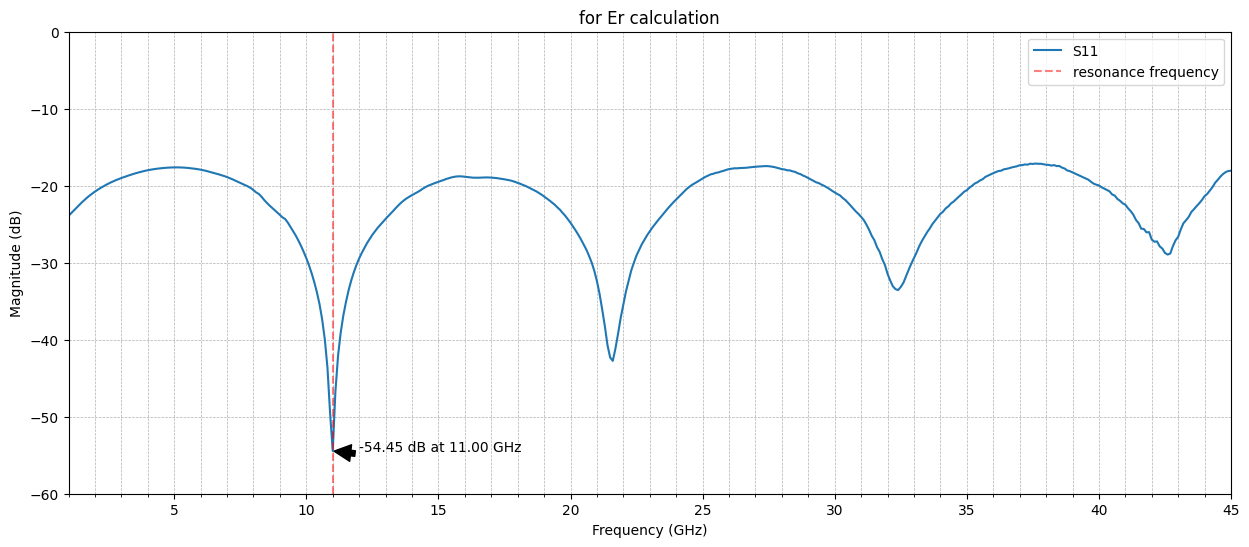

In [157]:
plt.figure(figsize=(15,6))

#changinf axis ticks
from matplotlib.ticker import MultipleLocator
ax = plt.gca()
# Set grid lines at every 3 dB on the y-axis
# ax.yaxis.set_major_locator(MultipleLocator(3))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1e9))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)


plt.title("for Er calculation")
nk = rf.Network(thru_files_all[6])
nk = smooth_network(nk, window=11, poly=3)
s11_db = nk.s_db[:, 0, 0]
minima_freq = nk.frequency[np.where(s11_db == min(s11_db))][0].f.item()
S11_db_min = min(s11_db).item()
nk.frequency.unit = 'GHz'
nk.plot_s_db(m=0,n=0)
plt.axvline(x=minima_freq, color='r', linestyle='--', label='resonance frequency', alpha=0.5)
ax.annotate(f'{S11_db_min:.2f} dB at {minima_freq/1e9:.2f} GHz', 
            xy=(minima_freq, S11_db_min),          # Point to point to
            xytext=(minima_freq + 1e9, S11_db_min),  # Location of the text label
            arrowprops=dict(facecolor='black', shrink=0.05), # Optional arrow
            fontsize=10)
plt.ylim(-60,0)
plt.legend()

In [156]:
S11_db_min

-54.453496266750925

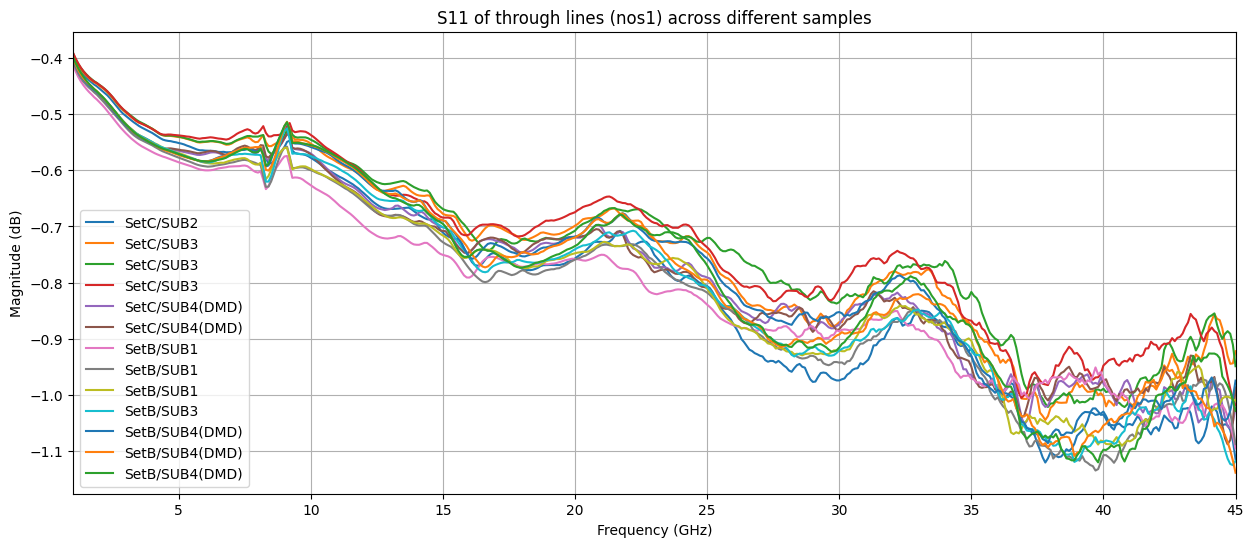

In [12]:
# plotting the S11 of through lines nos1
plt.figure(figsize=(15,6))
plt.title("S11 of through lines (nos1) across different samples")

#changinf axis ticks
from matplotlib.ticker import MultipleLocator
ax = plt.gca()
# Set grid lines at every 3 dB on the y-axis
# ax.yaxis.set_major_locator(MultipleLocator(3))
plt.grid(True)

for path in thru_files_all:
    path_obj = Path(path)
    # Extract the last two directories (excluding the file name)
    # path_obj.parts contains ('C:', 'Users', ..., 'TrialA', 'results.csv')
    folder_label = "/".join(path_obj.parts[-3:-1])  # Get the last two directories

    ntwk = rf.Network(path)
    sm_ntwk = smooth_network(ntwk, window=11, poly=3)
    sm_ntwk.frequency.unit = 'GHz'
    sm_ntwk.plot_s_db(m=1,n=0, label=folder_label)

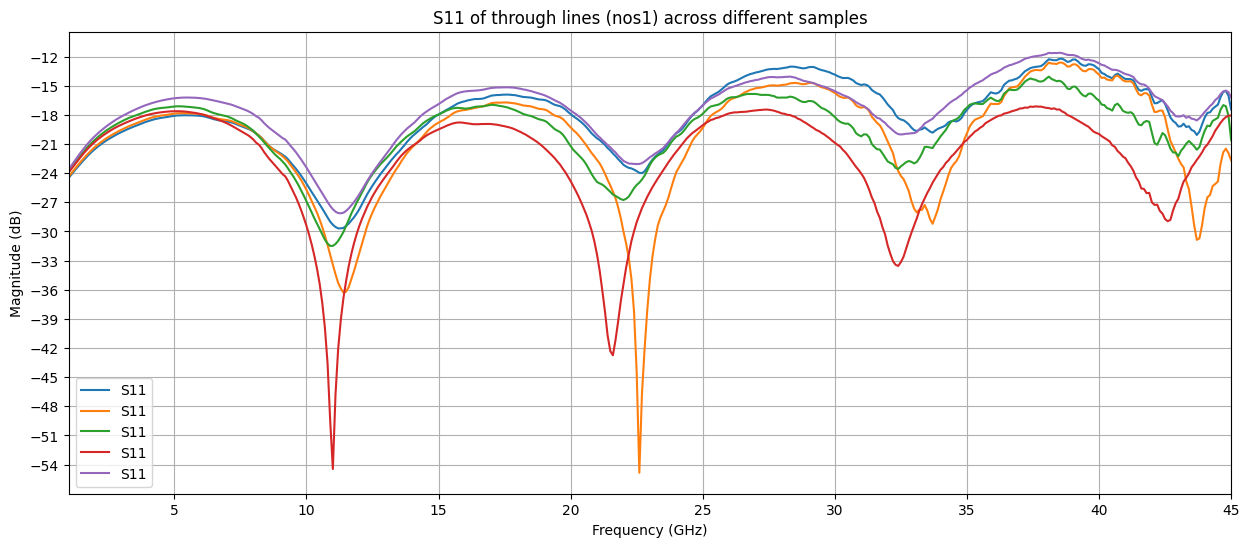

In [85]:
# plotting the S11 of through lines nos1
plt.figure(figsize=(15,6))
plt.title("S11 of through lines (nos1) across different samples")
from matplotlib.ticker import MultipleLocator

ax = plt.gca()
# Set grid lines at every 1.5 units
ax.yaxis.set_major_locator(MultipleLocator(3))
plt.grid(True)

# plt.grid(which='both', linestyle='--', linewidth=0.5)
for path in thru_files_nos1:
    ntwk = rf.Network(path)
    sm_ntwk = smooth_network(ntwk, window=11, poly=3)
    sm_ntwk.frequency.unit = 'GHz'
    sm_ntwk.plot_s_db(m=0,n=0)

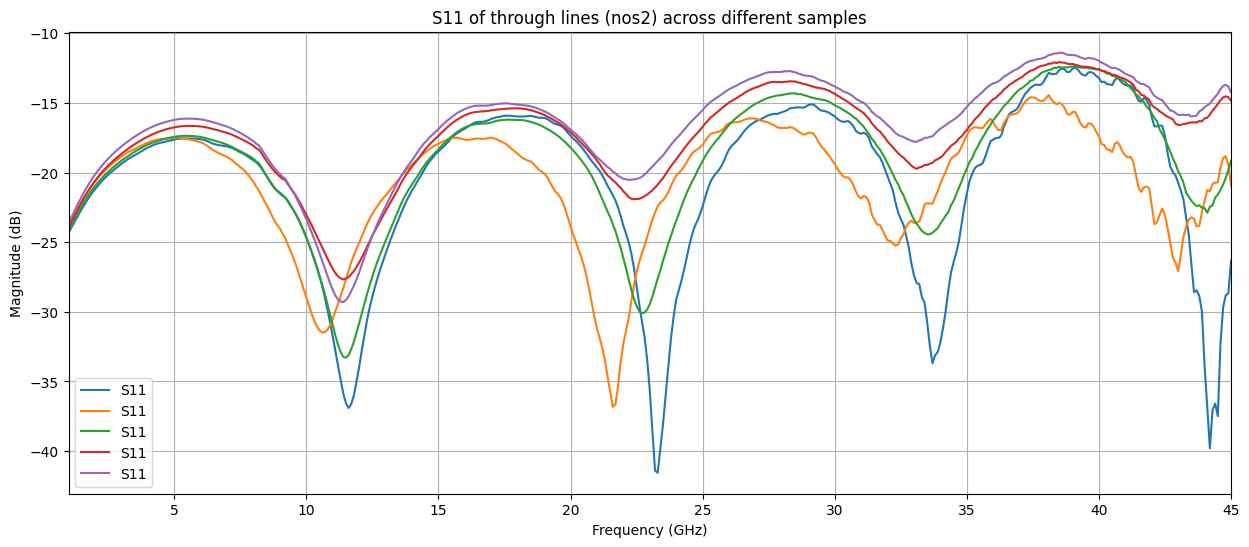

In [77]:
# plotting the S11 of through lines nos2
plt.figure(figsize=(15,6))
plt.title("S11 of through lines (nos2) across different samples")
plt.grid()
for path in thru_files_nos2:
    ntwk = rf.Network(path)
    sm_ntwk = smooth_network(ntwk, window=11, poly=3)
    sm_ntwk.frequency.unit = 'GHz'
    sm_ntwk.plot_s_db(m=0,n=0)

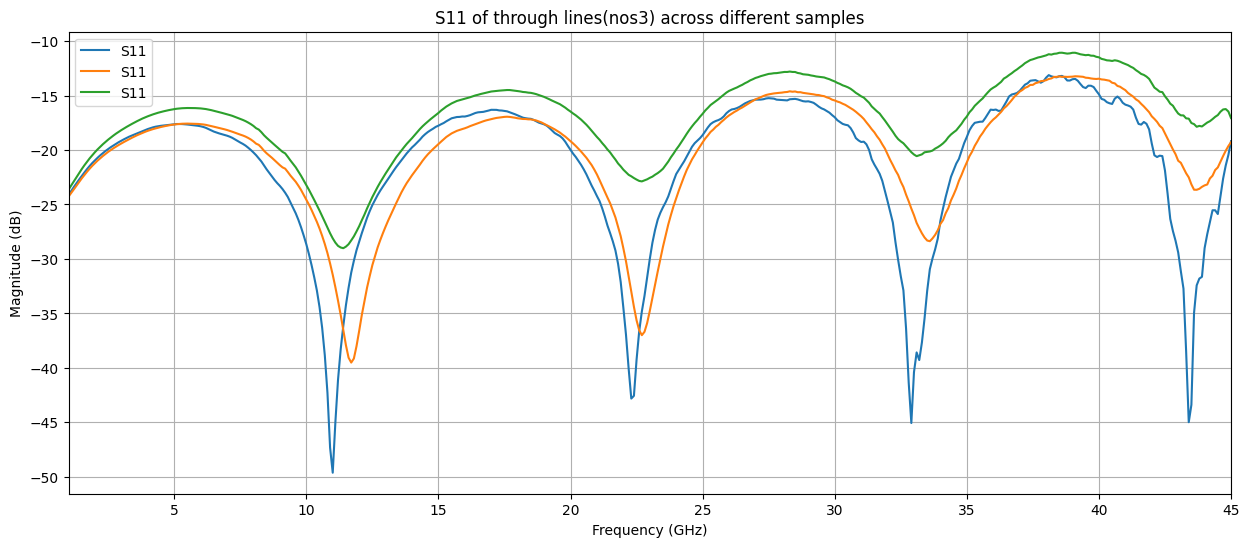

In [80]:
# plotting the S11 of through lines nos3
plt.figure(figsize=(15,6))
plt.title("S11 of through lines(nos3) across different samples")
plt.grid()
for path in thru_files_nos3:
    ntwk = rf.Network(path)
    sm_ntwk = smooth_network(ntwk, window=11, poly=3)
    sm_ntwk.frequency.unit = 'GHz'
    sm_ntwk.plot_s_db(m=0,n=0)

(-56.0, 0.0)

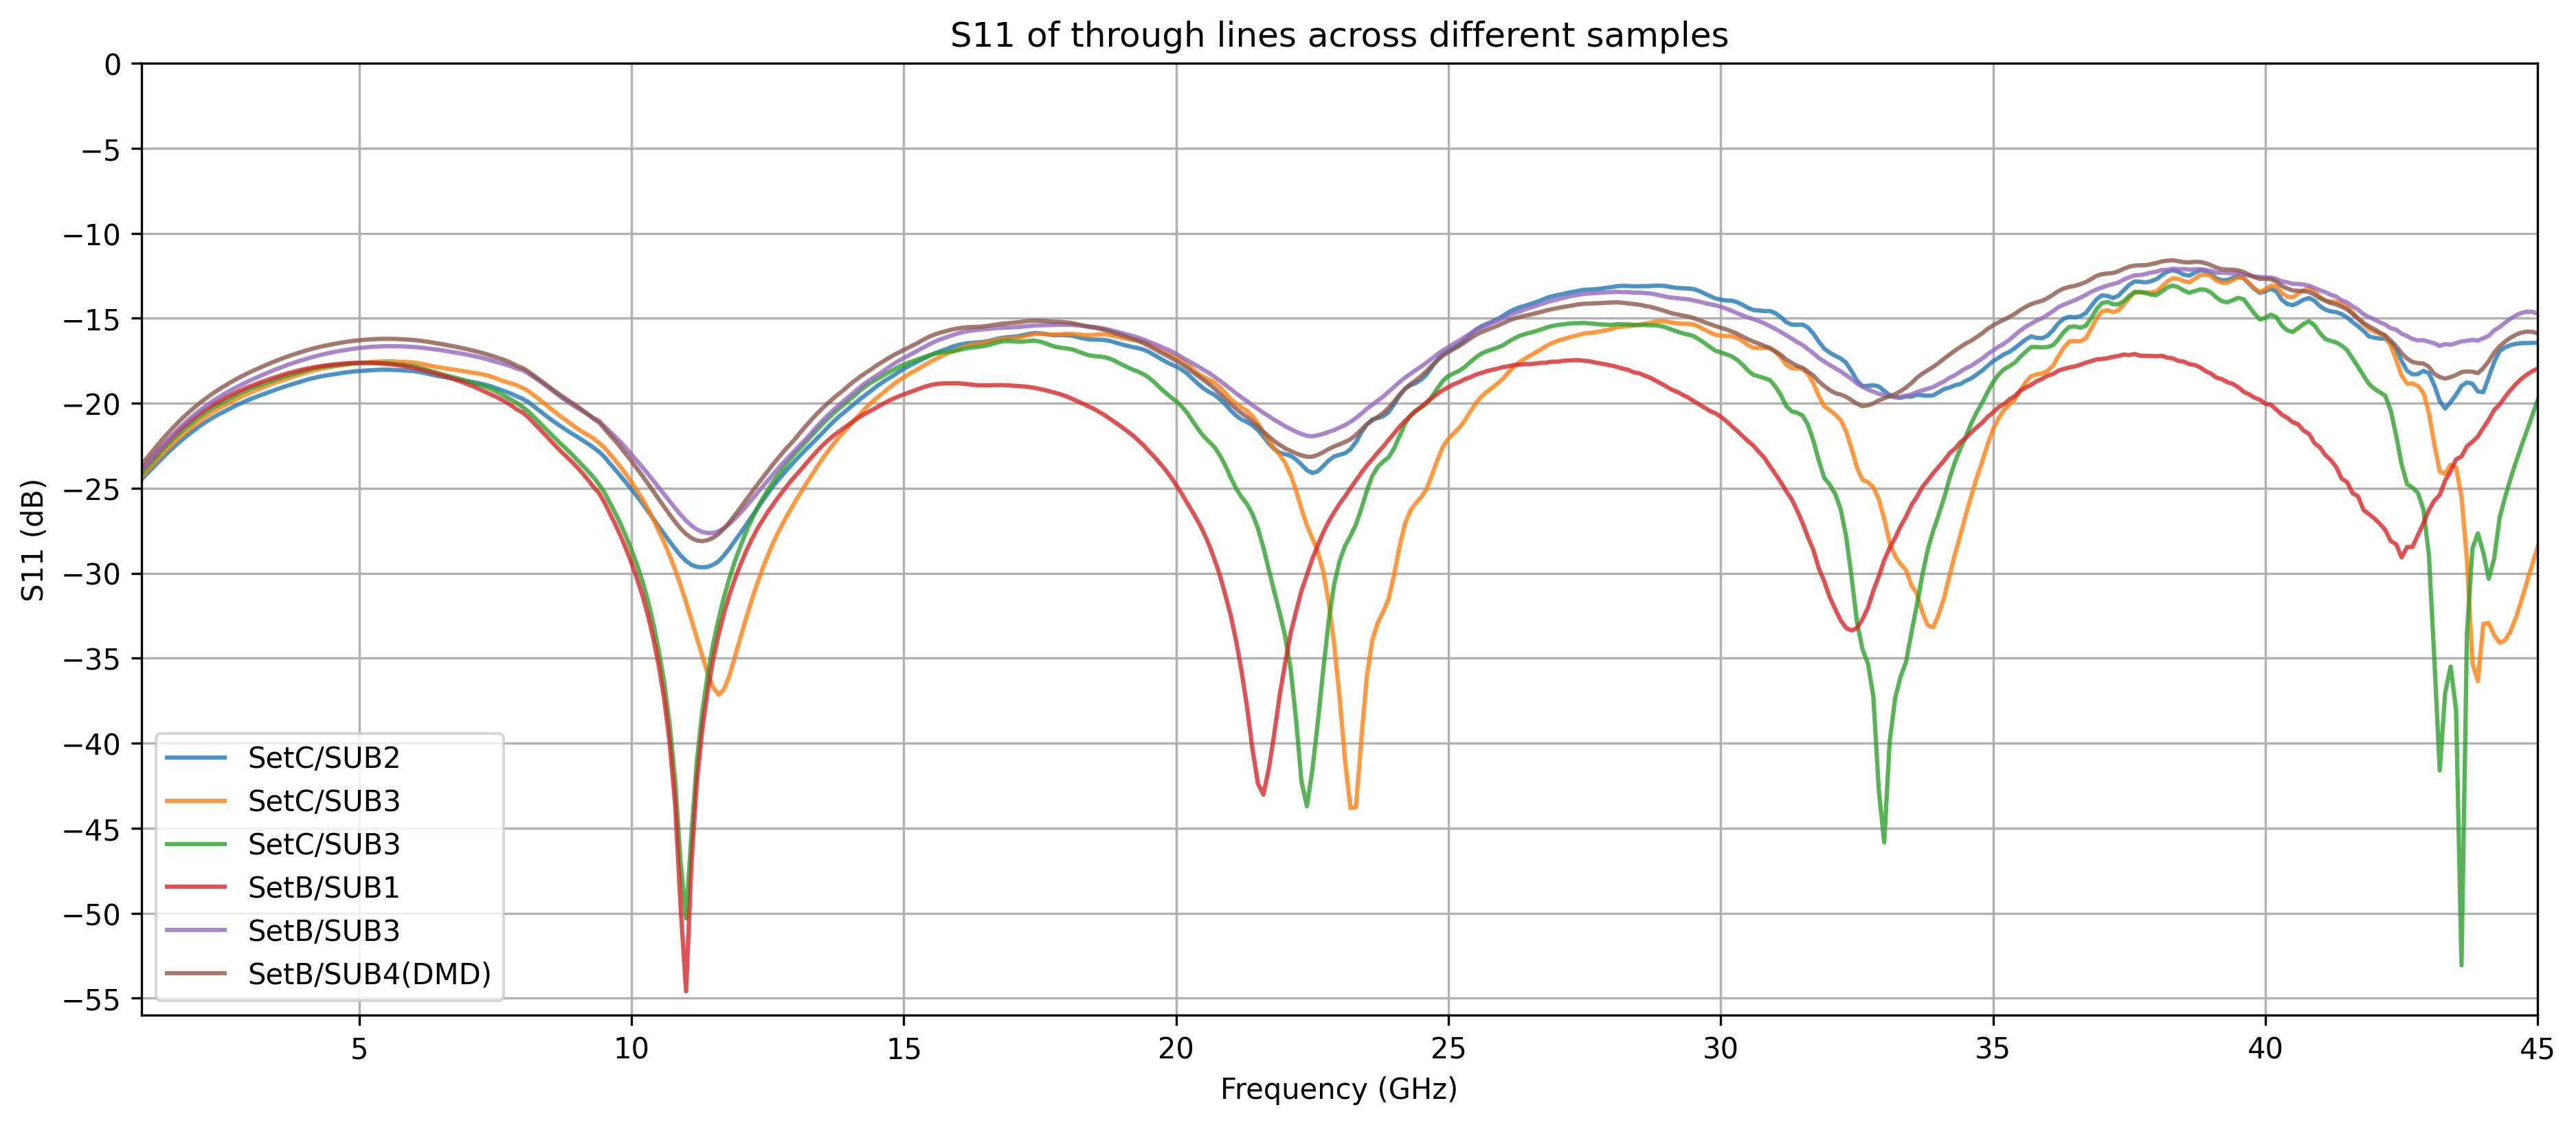

In [120]:
# choosing the graohs which show the best and worst return loss across all samples for through lines nos1, nos2 and nos3
plt.figure(figsize=(15, 6), dpi=300)
plt.title("S11 of through lines across different samples")

#changinf axis ticks
from matplotlib.ticker import MultipleLocator
ax = plt.gca()
# ax.axvspan(27e9, 40e9, color="#f0f0f089", alpha=0.7, label='Target Band (27-40 GHz)')
# Set grid lines at every 3 dB on the y-axis
ax.yaxis.set_major_locator(MultipleLocator(5))
plt.grid(True)



for path in [thru_files_all[x] for x in(0,2,3,6,9,10)]:
    path_obj = Path(path)
    # Extract the last two directories (excluding the file name)
    # path_obj.parts contains ('C:', 'Users', ..., 'TrialA', 'results.csv')
    folder_label = "/".join(path_obj.parts[-3:-1])  # Get the last two directories

    ntwk = rf.Network(path)
    sm_ntwk = smooth_network(ntwk, window=15, poly=3)
    sm_ntwk.frequency.unit = 'GHz'
    sm_ntwk.plot_s_db(m=0,n=0, label=folder_label, linewidth=1.5, alpha=0.8)
plt.ylabel("S11 (dB)")
plt.ylim(-56, 0)  # Set y-axis limits to focus on the range of interest


(-1.2, 0.0)

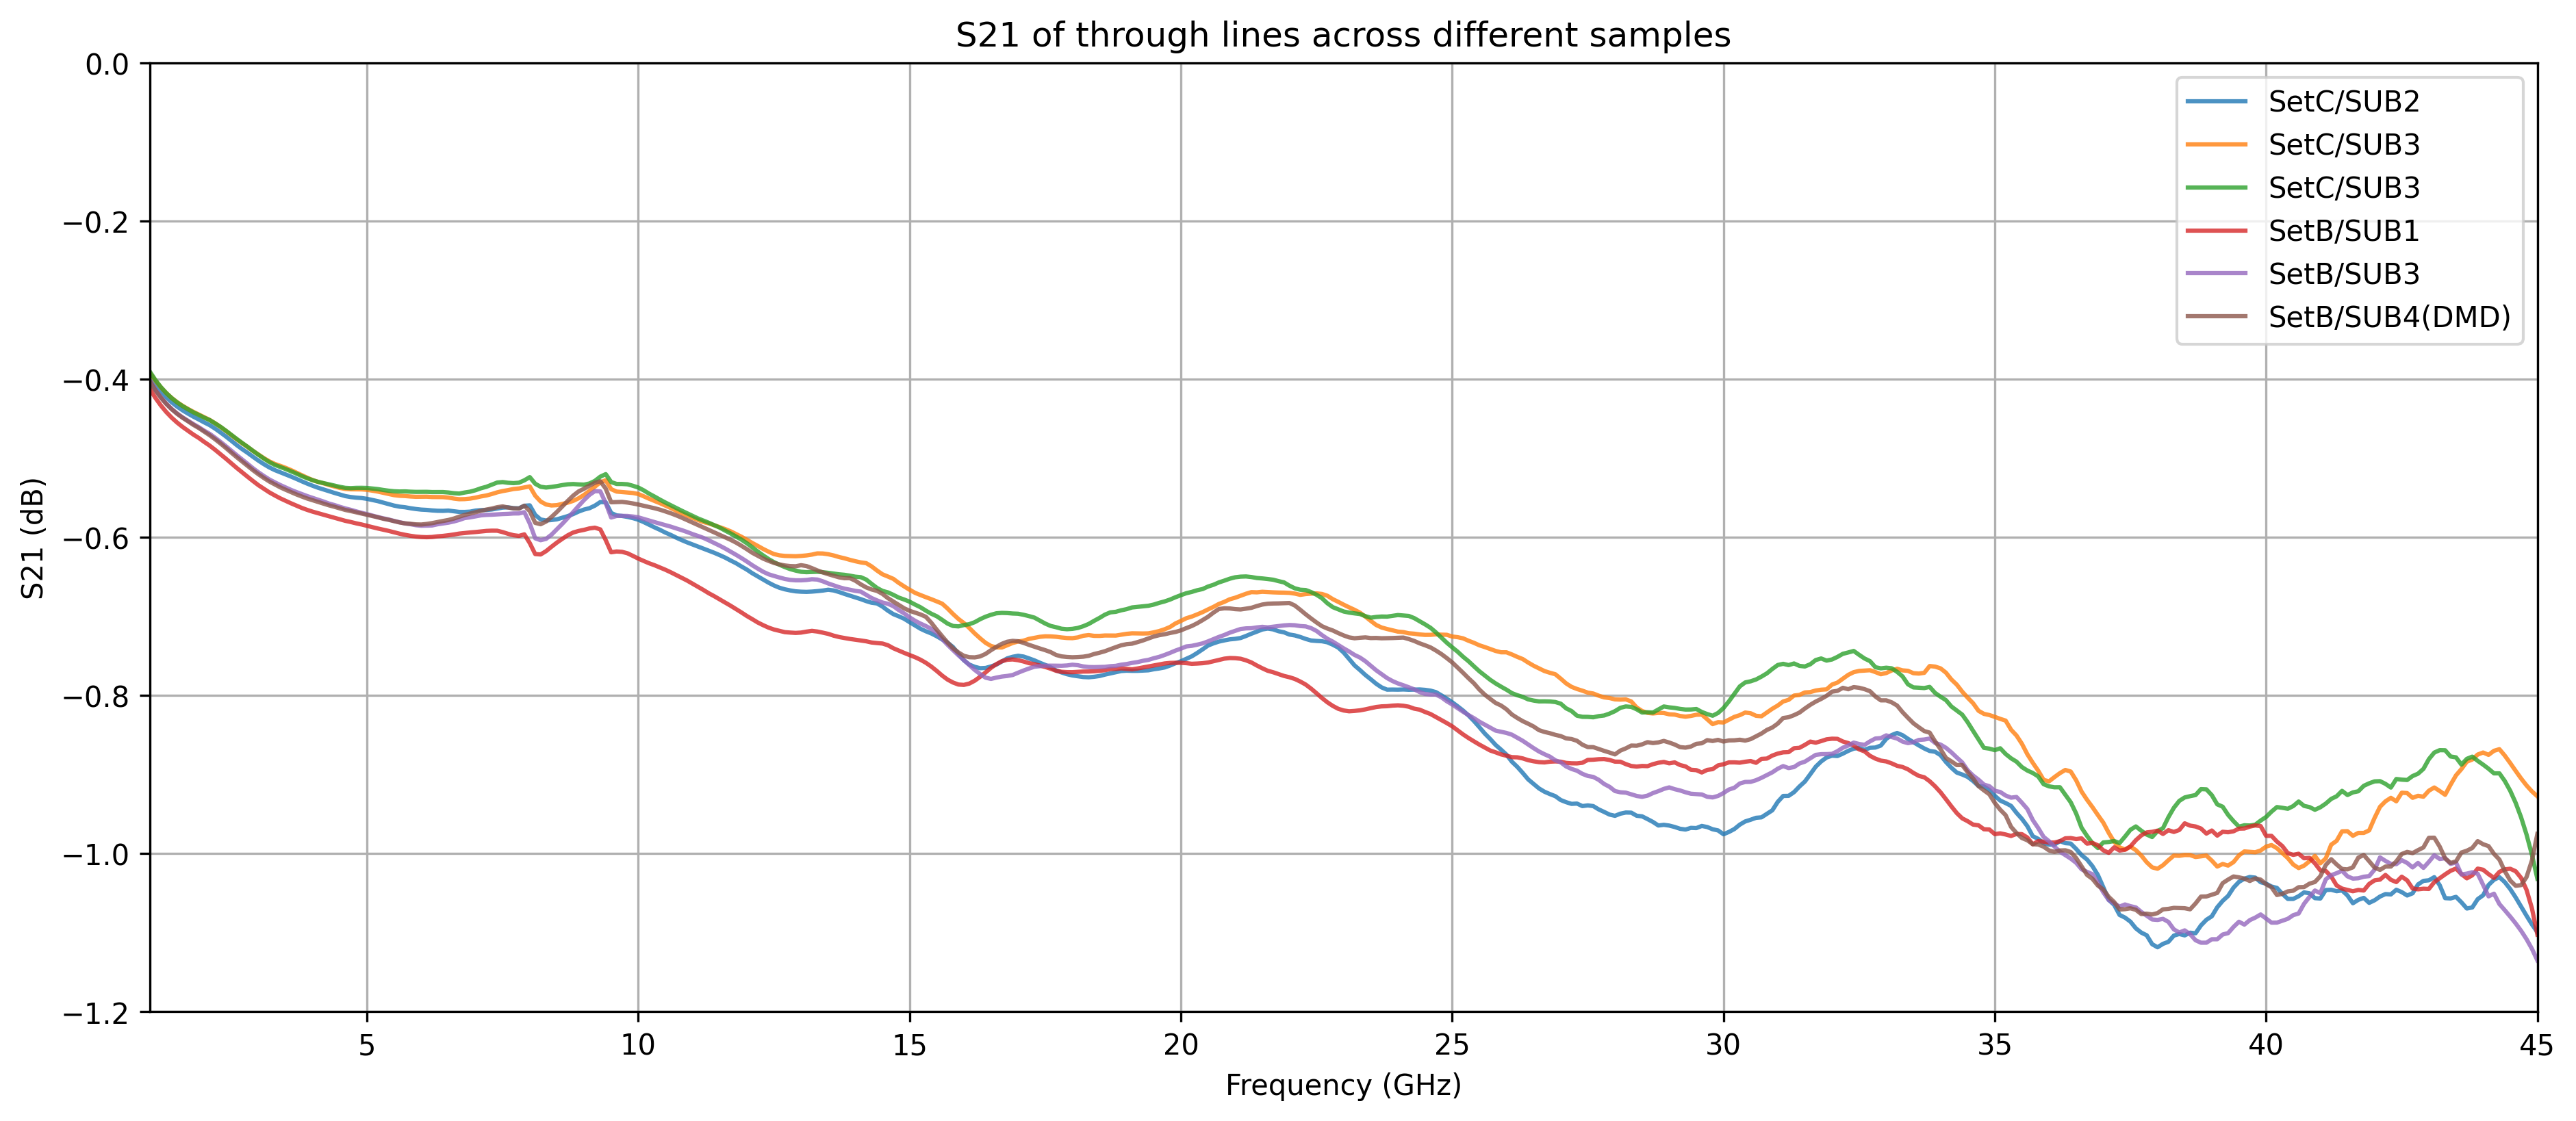

In [126]:
# choosing the graohs which show the best and worst return loss across all samples for through lines nos1, nos2 and nos3
plt.figure(figsize=(15, 6), dpi=300)
plt.title("S21 of through lines across different samples")

# #changinf axis ticks
# from matplotlib.ticker import MultipleLocator
# ax = plt.gca()
# # ax.axvspan(27e9, 40e9, color="#f0f0f089", alpha=0.7, label='Target Band (27-40 GHz)')
# # Set grid lines at every 3 dB on the y-axis
# ax.yaxis.set_major_locator(MultipleLocator(5))
plt.grid(True, which='both')



for path in [thru_files_all[x] for x in(0,2,3,6,9,10)]:
    path_obj = Path(path)
    # Extract the last two directories (excluding the file name)
    # path_obj.parts contains ('C:', 'Users', ..., 'TrialA', 'results.csv')
    folder_label = "/".join(path_obj.parts[-3:-1])  # Get the last two directories

    ntwk = rf.Network(path)
    sm_ntwk = smooth_network(ntwk, window=15, poly=3)
    sm_ntwk.frequency.unit = 'GHz'
    sm_ntwk.plot_s_db(m=1,n=0, label=folder_label, linewidth=1.5, alpha=0.8)
plt.ylabel("S21 (dB)")
plt.ylim(-1.2, 0)  # Set y-axis limits to focus on the range of interest


(-55.0, 0.0)

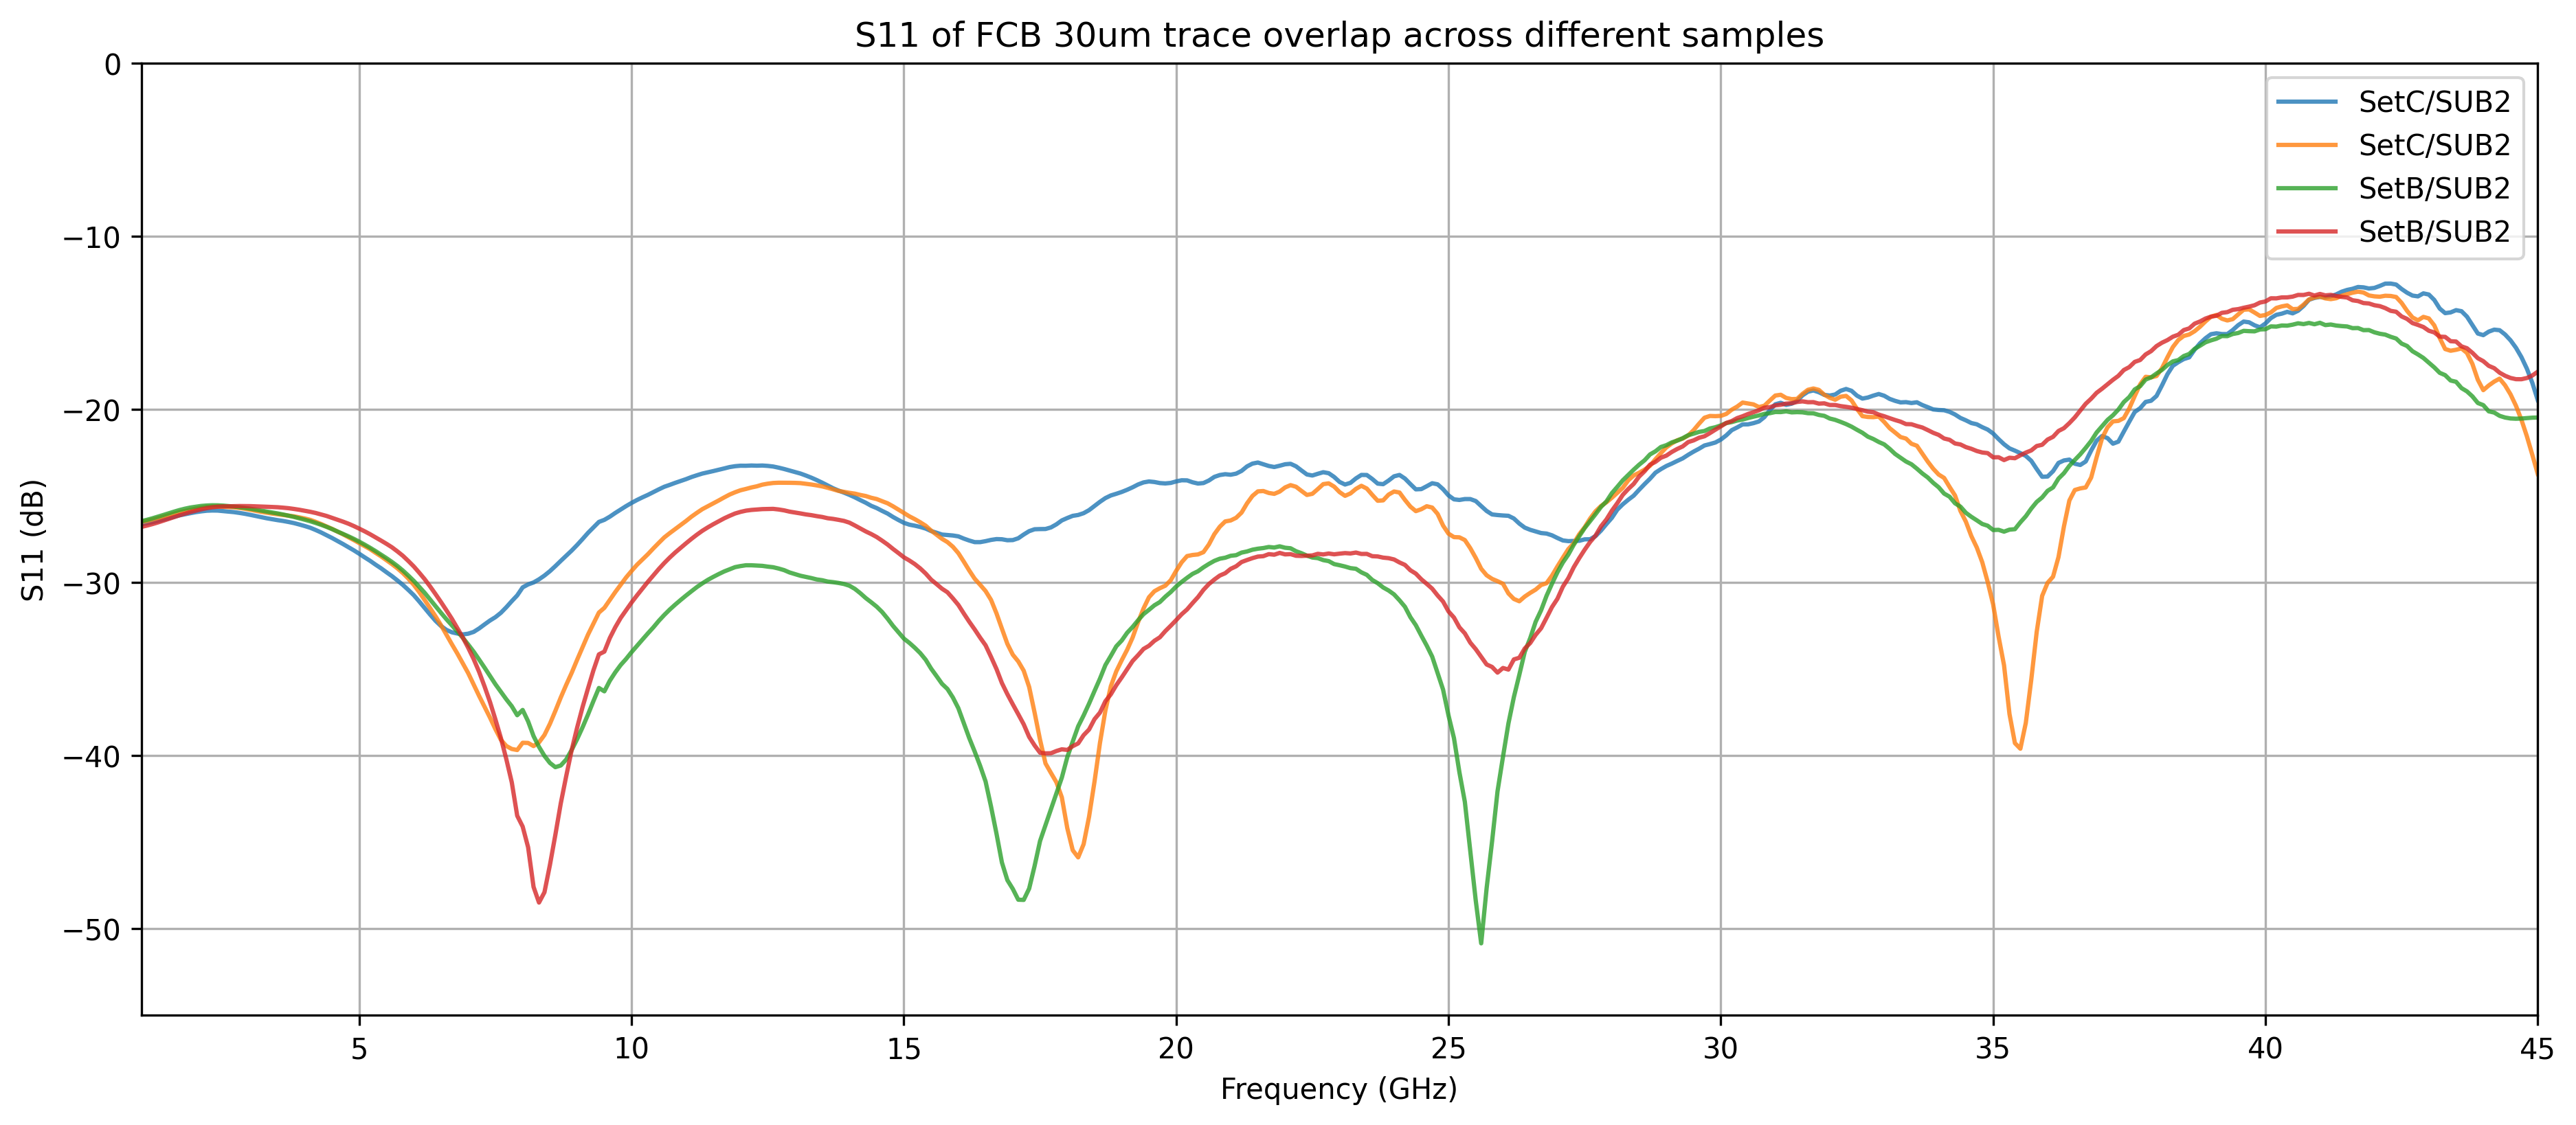

In [140]:
# choosing the graohs which show the best and worst return loss across all samples for through lines nos1, nos2 and nos3
plt.figure(figsize=(15, 6), dpi=300)
plt.title("S11 of FCB 30um trace overlap across different samples")

# #changinf axis ticks
# from matplotlib.ticker import MultipleLocator
# ax = plt.gca()
# # ax.axvspan(27e9, 40e9, color="#f0f0f089", alpha=0.7, label='Target Band (27-40 GHz)')
# # Set grid lines at every 3 dB on the y-axis
# ax.yaxis.set_major_locator(MultipleLocator(5))
plt.grid(True, which='both')



for path in FCB_tr_overlap_30um:
    path_obj = Path(path)
    # Extract the last two directories (excluding the file name)
    # path_obj.parts contains ('C:', 'Users', ..., 'TrialA', 'results.csv')
    folder_label = "/".join(path_obj.parts[-3:-1])  # Get the last two directories

    ntwk = rf.Network(path)
    ntwk = smooth_network(ntwk, window=15, poly=3)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0, label=folder_label, linewidth=1.5, alpha=0.8)
plt.ylabel("S11 (dB)")
plt.ylim(-55, 0)  # Set y-axis limits to focus on the range of interest

(-1.4, 0.0)

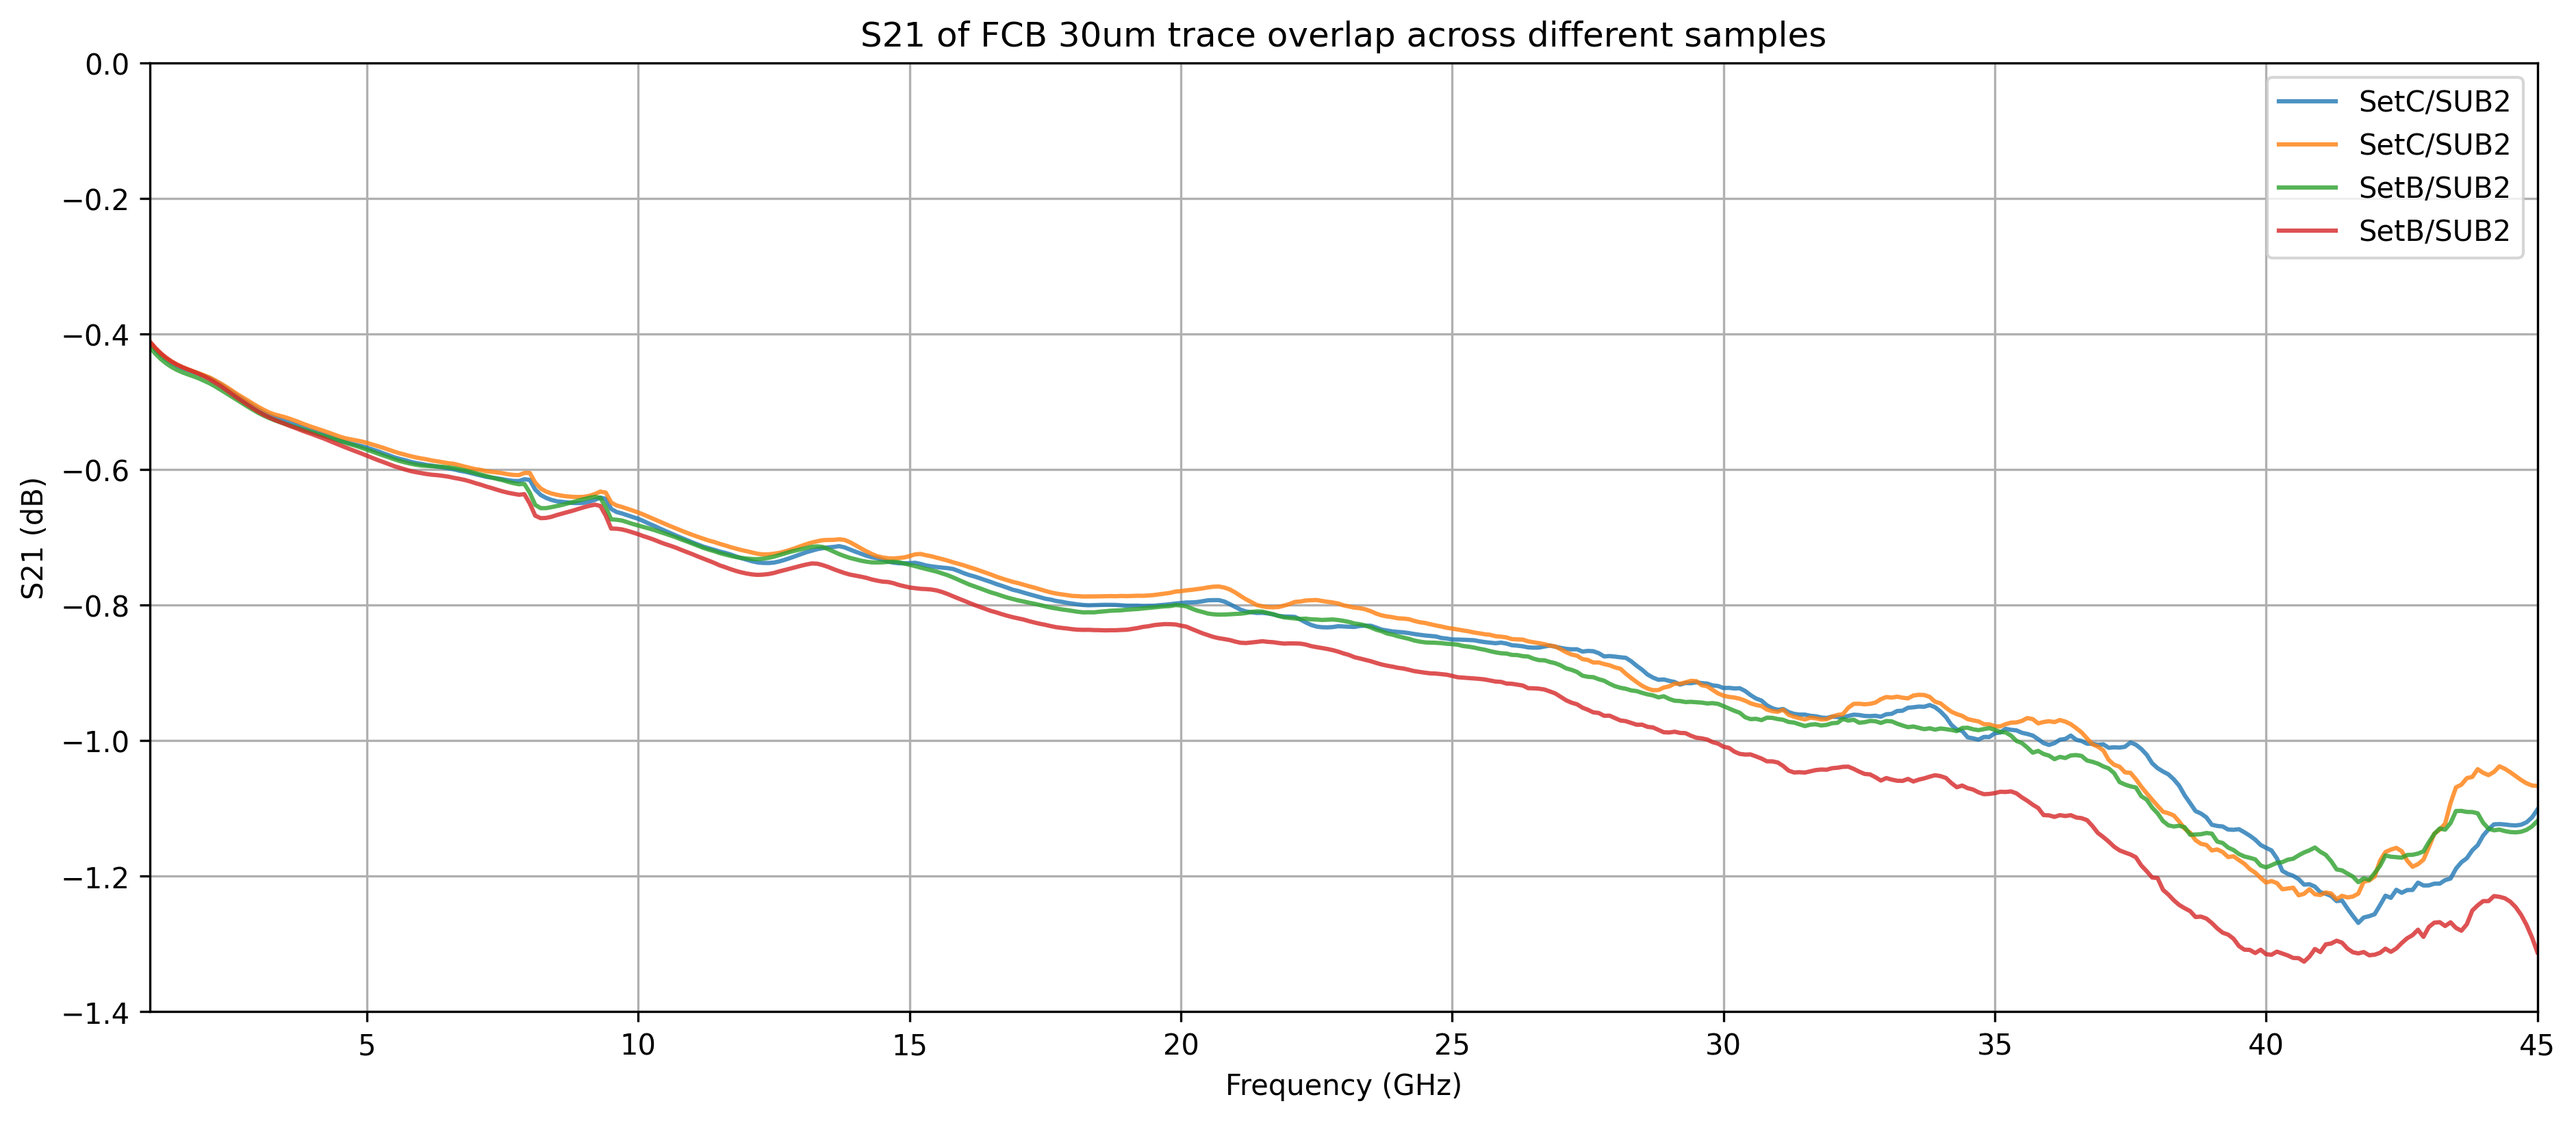

In [145]:
# choosing the graohs which show the best and worst return loss across all samples for through lines nos1, nos2 and nos3
plt.figure(figsize=(15, 6), dpi=300)
plt.title("S21 of FCB 30um trace overlap across different samples")

# #changinf axis ticks
# from matplotlib.ticker import MultipleLocator
# ax = plt.gca()
# # ax.axvspan(27e9, 40e9, color="#f0f0f089", alpha=0.7, label='Target Band (27-40 GHz)')
# # Set grid lines at every 3 dB on the y-axis
# ax.yaxis.set_major_locator(MultipleLocator(5))
plt.grid(True, which='both')



for path in FCB_tr_overlap_30um:
    path_obj = Path(path)
    # Extract the last two directories (excluding the file name)
    # path_obj.parts contains ('C:', 'Users', ..., 'TrialA', 'results.csv')
    folder_label = "/".join(path_obj.parts[-3:-1])  # Get the last two directories

    ntwk = rf.Network(path)
    ntwk = smooth_network(ntwk, window=15, poly=3)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=0, label=folder_label, linewidth=1.5, alpha=0.8)
plt.ylabel("S21 (dB)")
plt.ylim(-1.4, 0)  # Set y-axis limits to focus on the range of interest

(-55.0, 0.0)

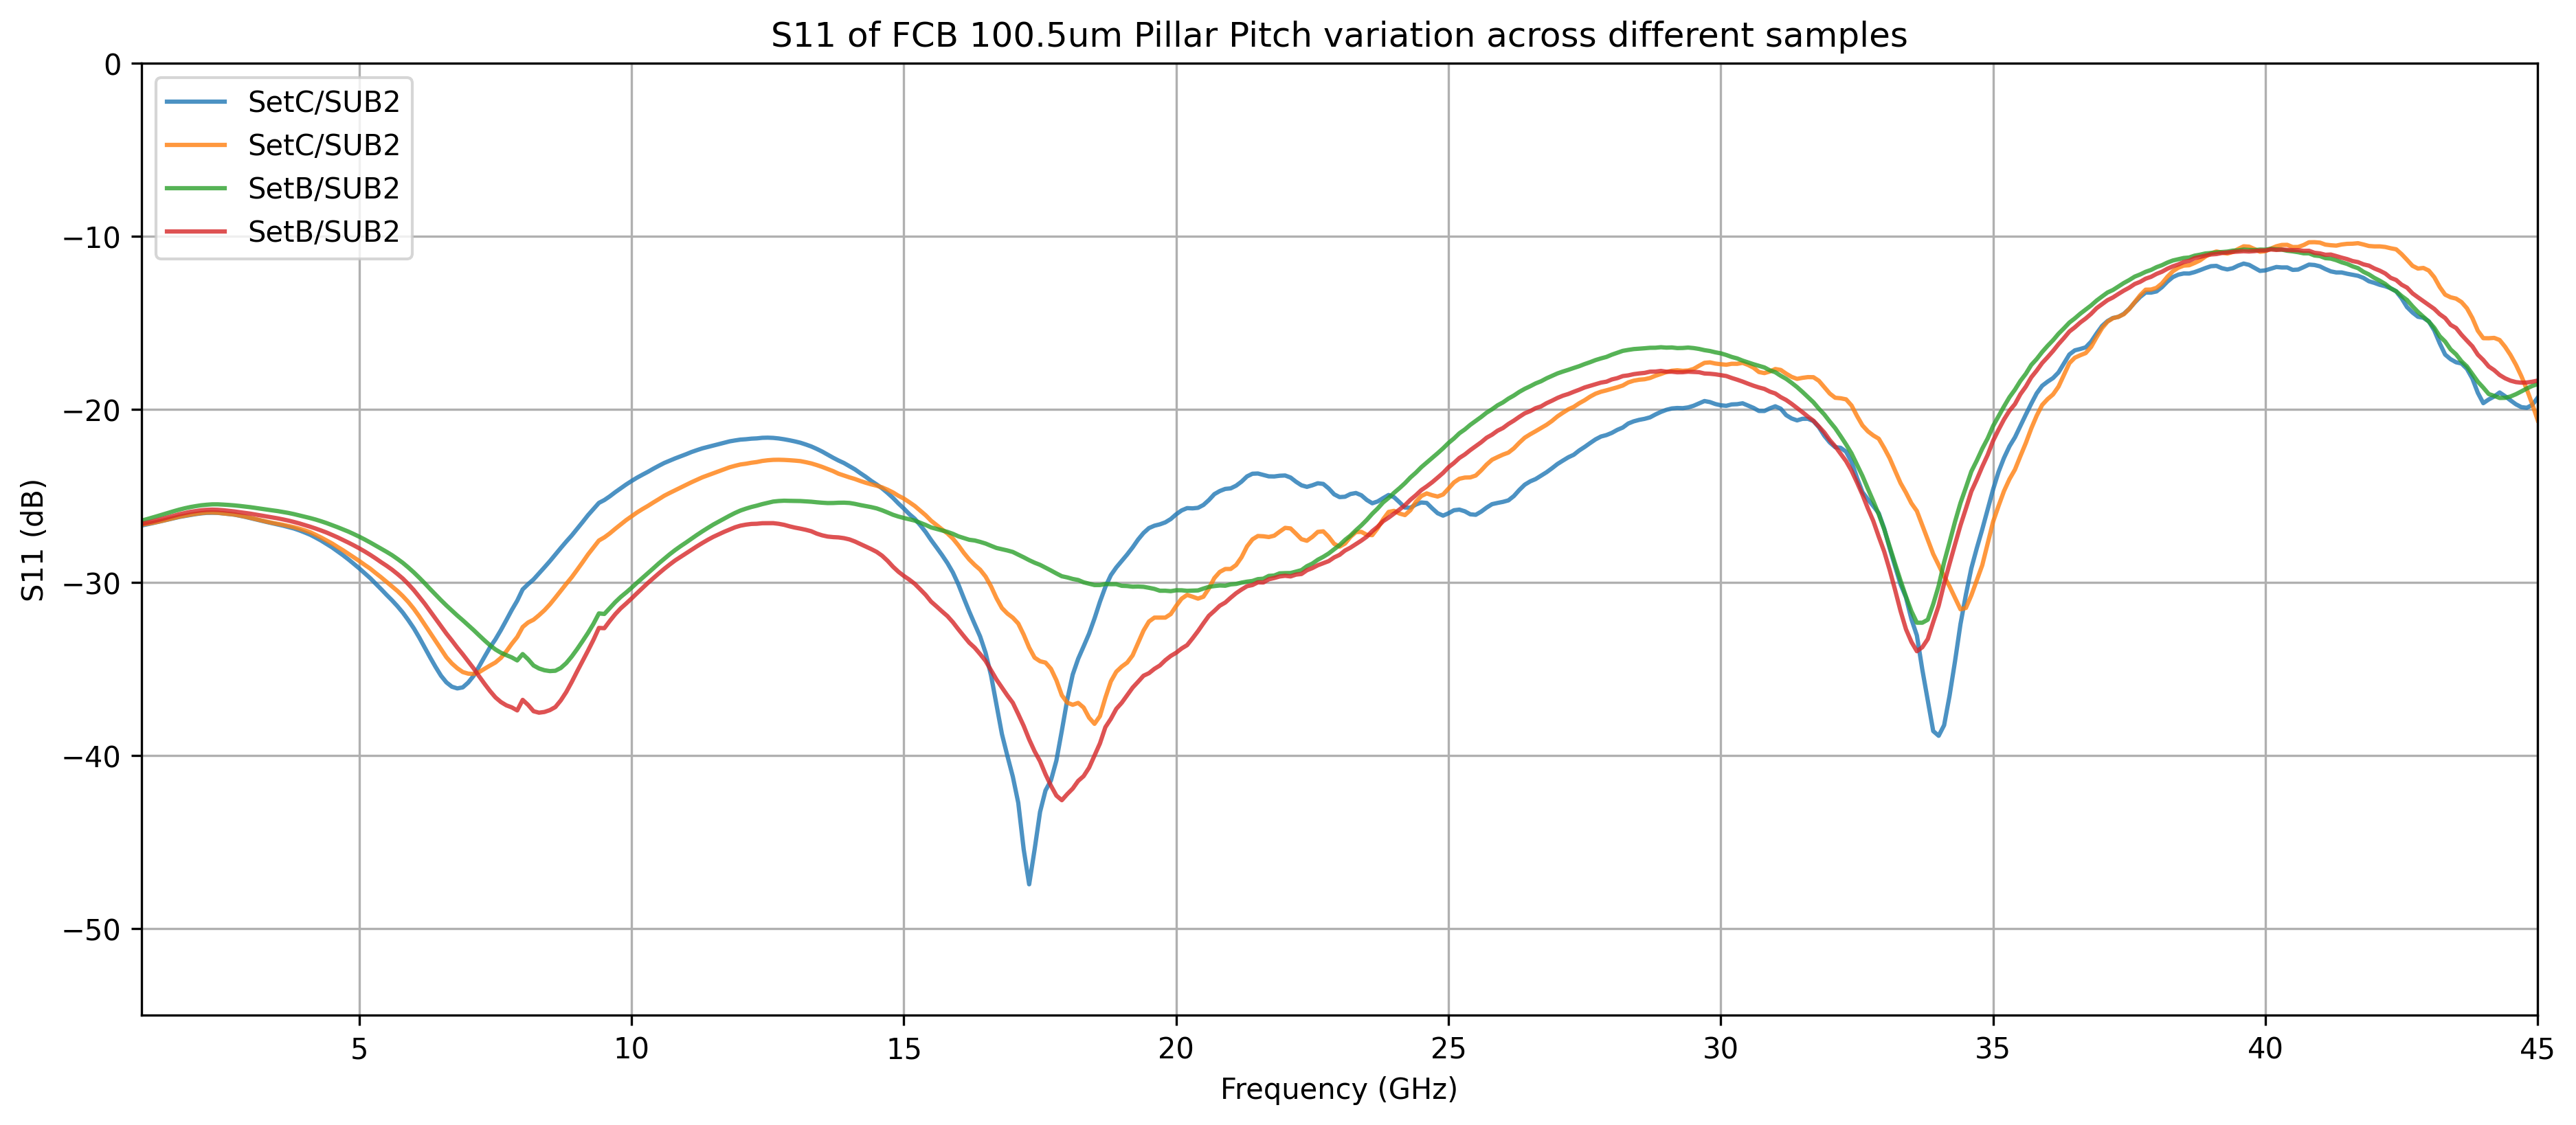

In [153]:
# choosing the graohs which show the best and worst return loss across all samples for through lines nos1, nos2 and nos3
plt.figure(figsize=(15, 6), dpi=300)
plt.title("S11 of FCB 100.5um Pillar Pitch variation across different samples")

# #changinf axis ticks
# from matplotlib.ticker import MultipleLocator
# ax = plt.gca()
# # ax.axvspan(27e9, 40e9, color="#f0f0f089", alpha=0.7, label='Target Band (27-40 GHz)')
# # Set grid lines at every 3 dB on the y-axis
# ax.yaxis.set_major_locator(MultipleLocator(5))
plt.grid(True, which='both')



for path in FCB_pillar_pitch_100um:
    path_obj = Path(path)
    # Extract the last two directories (excluding the file name)
    # path_obj.parts contains ('C:', 'Users', ..., 'TrialA', 'results.csv')
    folder_label = "/".join(path_obj.parts[-3:-1])  # Get the last two directories

    ntwk = rf.Network(path)
    ntwk = smooth_network(ntwk, window=15, poly=3)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0, label=folder_label, linewidth=1.5, alpha=0.8)
plt.ylabel("S11 (dB)")
plt.ylim(-55, 0)  # Set y-axis limits to focus on the range of interest

In [ ]:
# to calculate the stats of S-parameters at specific frequencies across all samples, we can use the following code:
import numpy as np
import skrf as rf

# Assume you have a list of network objects
networks = [rf.Network(path) for path in thru_files_all]

# Target frequencies in Hz
target_freqs = np.array([5e9, 20e9, 40e9])  # 5, 20, 40 GHz

# Extract S-parameters in dB using scikit-rf method
s_params_db = np.array([ntwk.s_db for ntwk in networks])  # Shape: (num_networks, num_freq, ports, ports)

# Get frequency array from first network
freqs = networks[0].frequency.f

# Find indices closest to target frequencies
indices = [np.argmin(np.abs(freqs - f)) for f in target_freqs]

# Extract S-parameters at those frequencies (in dB)
s_at_targets_db = s_params_db[:, indices, :, :]  # Shape: (num_networks, 3, ports, ports)

# Compute statistics across networks (axis 0) in dB
mean_s_db = np.mean(s_at_targets_db, axis=0)      # Shape: (3, ports, ports)
std_s_db = np.std(s_at_targets_db, axis=0)        # Shape: (3, ports, ports)
var_s_db = np.var(s_at_targets_db, axis=0)        # Shape: (3, ports, ports)

# # Access results for each frequency
# for i, (f, idx) in enumerate(zip(target_freqs/1e9, indices)):
#     print(f"\n=== {f} GHz (index {idx}) ===")
#     print(f"Mean S-parameters (dB):\n{mean_s_db[i]}")
#     print(f"Std Dev (dB):\n{std_s_db[i]}")
#     print(f"Variance (dB²):\n{var_s_db[i]}")

# Or for specific S-parameters (e.g., S11 in dB):
s11_at_targets_db = s_at_targets_db[:, :, 0, 0]  # Shape: (num_networks, 3)
s21_at_targets_db = s_at_targets_db[:, :, 1, 0]  # Shape: (num_networks, 3)
print(f"\nS11 Mean (dB): {np.mean(s11_at_targets_db, axis=0)}")
print(f"S11 Std Dev (dB): {np.std(s11_at_targets_db, axis=0)}")
# print(f"S11 Variance (dB²): {np.var(s11_at_targets_db, axis=0)}")
print(f"\nS21 Mean (dB): {np.mean(s21_at_targets_db, axis=0)}")
print(f"S21 Std Dev (dB): {np.std(s21_at_targets_db, axis=0)}")
# print(f"S21 Variance (dB²): {np.var(s21_at_targets_db, axis=0)}")


S11 Mean (dB): [-17.24685415 -19.20327008 -13.33201408]
S11 Std Dev (dB): [0.62316693 2.53347533 2.11070564]

S21 Mean (dB): [-0.5633532  -0.7270397  -1.01896808]
S21 Std Dev (dB): [0.01469848 0.02501741 0.06647993]


In [159]:
# to calculate the stats of S-parameters at specific frequencies across all samples, we can use the following code:
import numpy as np
import skrf as rf

# Assume you have a list of network objects
networks = [rf.Network(path) for path in FCB_tr_overlap_30um]

# Target frequencies in Hz
target_freqs = np.array([5e9, 20e9, 40e9])  # 5, 20, 40 GHz

# Extract S-parameters in dB using scikit-rf method
s_params_db = np.array([ntwk.s_db for ntwk in networks])  # Shape: (num_networks, num_freq, ports, ports)

# Get frequency array from first network
freqs = networks[0].frequency.f

# Find indices closest to target frequencies
indices = [np.argmin(np.abs(freqs - f)) for f in target_freqs]

# Extract S-parameters at those frequencies (in dB)
s_at_targets_db = s_params_db[:, indices, :, :]  # Shape: (num_networks, 3, ports, ports)

# Compute statistics across networks (axis 0) in dB
mean_s_db = np.mean(s_at_targets_db, axis=0)      # Shape: (3, ports, ports)
std_s_db = np.std(s_at_targets_db, axis=0)        # Shape: (3, ports, ports)
var_s_db = np.var(s_at_targets_db, axis=0)        # Shape: (3, ports, ports)

# # Access results for each frequency
# for i, (f, idx) in enumerate(zip(target_freqs/1e9, indices)):
#     print(f"\n=== {f} GHz (index {idx}) ===")
#     print(f"Mean S-parameters (dB):\n{mean_s_db[i]}")
#     print(f"Std Dev (dB):\n{std_s_db[i]}")
#     print(f"Variance (dB²):\n{var_s_db[i]}")

# Or for specific S-parameters (e.g., S11 in dB):
s11_at_targets_db = s_at_targets_db[:, :, 0, 0]  # Shape: (num_networks, 3)
s21_at_targets_db = s_at_targets_db[:, :, 1, 0]  # Shape: (num_networks, 3)
print(f"\nS11 Mean (dB): {np.mean(s11_at_targets_db, axis=0)}")
print(f"S11 Std Dev (dB): {np.std(s11_at_targets_db, axis=0)}")
# print(f"S11 Variance (dB²): {np.var(s11_at_targets_db, axis=0)}")
print(f"\nS21 Mean (dB): {np.mean(s21_at_targets_db, axis=0)}")
print(f"S21 Std Dev (dB): {np.std(s21_at_targets_db, axis=0)}")
# print(f"S21 Variance (dB²): {np.var(s21_at_targets_db, axis=0)}")


S11 Mean (dB): [-27.651773   -28.9651395  -13.64846775]
S11 Std Dev (dB): [0.51005494 2.91086854 0.69311401]

S21 Mean (dB): [-0.56951758 -0.80225967 -1.1959655 ]
S21 Std Dev (dB): [0.00685032 0.01897767 0.06614072]


<>:1: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:1: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\hrith\AppData\Local\Temp\ipykernel_11696\354456713.py:1: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  path = 'GEECI_mes\SetB\SUB3'


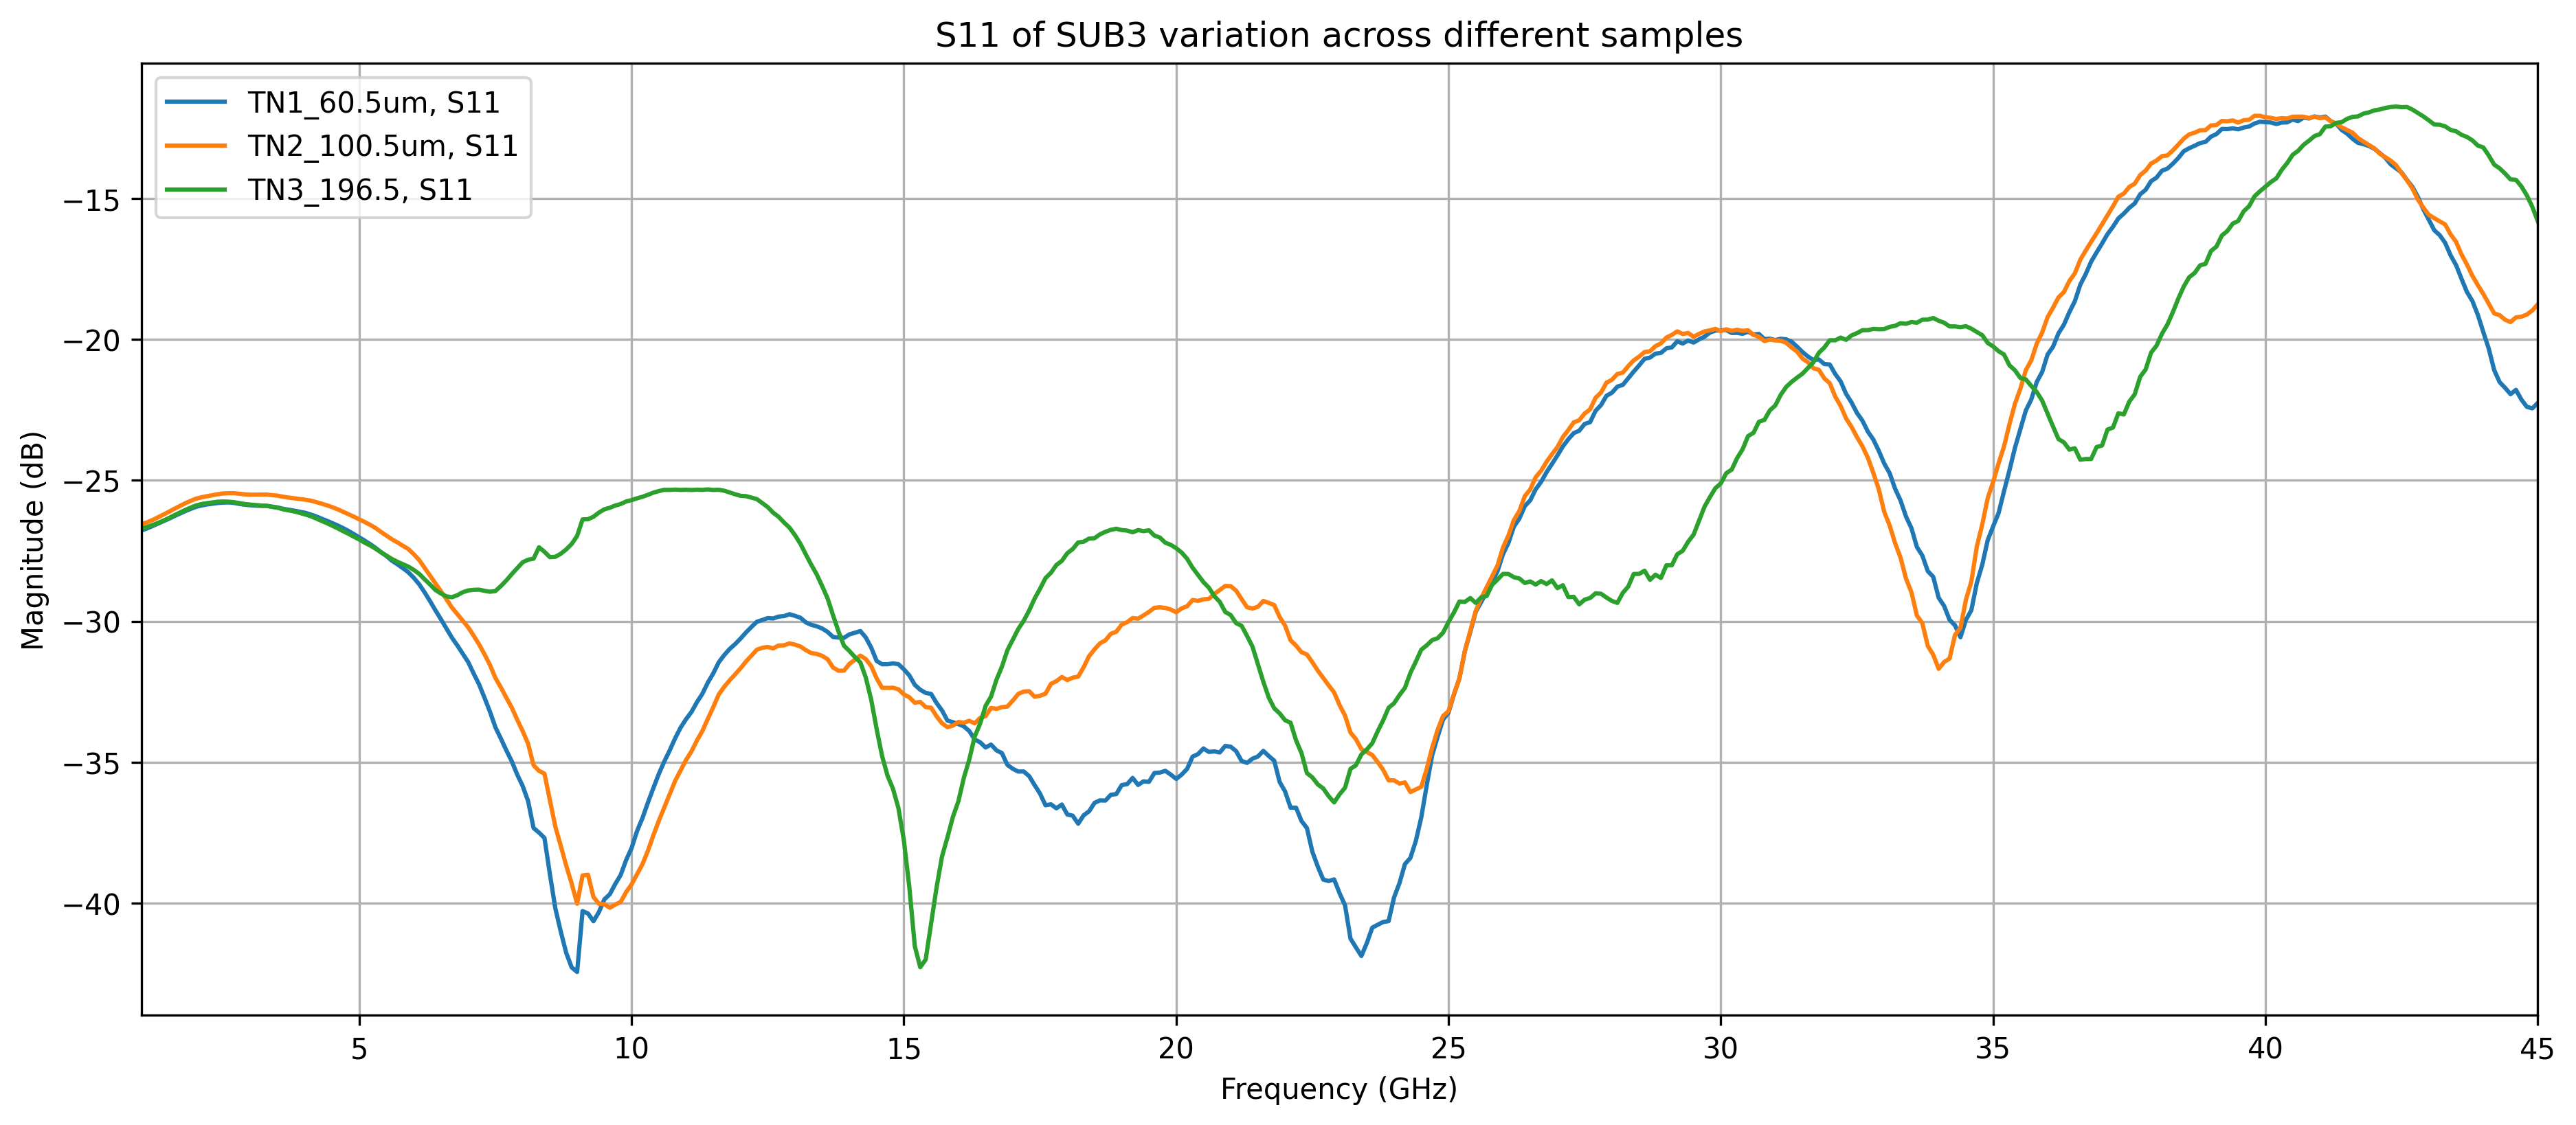

In [172]:
path = 'GEECI_mes\SetB\SUB3'
plt.figure(figsize=(15, 6), dpi=300)
plt.title("S11 of SUB3 variation across different samples")
plt.grid(True, which='both')
Sub3, Sub3_Smoothened = load_directory(path, window=9, poly=3)
for ntwk in Sub3_Smoothened[:3]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0)